# One kinetic framework for W, Zr and Eurofer-97

Every curve in this notebook comes from the same solver, `DislocationModel` in `unified_plasticity.py`. Each material only supplies different microstructure and processes (`material_cards.py`). No onset functions $S(T)$ or $S(d)$ are used.

### Composition rules
| The processes are… | combine by… | example |
|---|---|---|
| **sequential** for one segment | adding **times**: $1/\dot\gamma=\sum_i 1/\dot\gamma_i$ | kink-pair travel → waiting at an obstacle |
| **alternative** ways past one obstacle | adding **rates**: $\nu=\sum_k\nu_k$ | thermal detachment / glide-assisted climb |
| **simultaneous** along the line (dense-weak + sparse-strong) | adding **stresses** (Kocks superposition) | Peierls friction + athermal forest $\tau_a$; + precipitate group $\tau_{\rm ppt}$ |

$$\tau=\tau_a(\text{state})+\tau^\star_{\rm main}(\dot\gamma)+\sum_g\tau_g(\dot\gamma)$$

The state (forest density, $C/C_0$, $d$, …) may depend on $(\dot\gamma,T,\gamma)$ but never on $\tau$. Each stress is therefore unique for an imposed rate.

### Strain-rate sensitivity: the $A$–$B$ decomposition, computed rather than prescribed
$$A=\frac{\partial\ln\dot\gamma_{\rm intra}}{\partial\tau^\star},\qquad B=\frac{d\tau}{d\ln\dot\gamma}-\frac1A,\qquad \Lambda=AB,\qquad \frac1m=\frac{\tau A}{1+\Lambda},\qquad V^\star=\frac{k_BT}{m\tau}$$

* $A$ is the intrinsic mobility sensitivity: glide plus intragranular obstacles, in series.
* $B$ collects everything else:
  * superposed groups,
  * **rate-dependent state**. Solute aging gives $B<0$, and $\Lambda<-1\Leftrightarrow m<0$. Climb-controlled recovery gives $B>0$.

| material | travel | waiting (series) | simultaneous | rate-dependent state |
|---|---|---|---|---|
| **W** | kink pair + drag | – | Taylor forest $\tau_a$ | – ($\Lambda=0$) |
| **Zr** | prismatic kink pair | – | Taylor forest $\tau_a$ | O aging (DSA), climb recovery of the forest |
| **Eurofer-97** | kink pair | – | forest/laths; precipitates (detachment ∥ local climb) | C/N aging (DSA), climb recovery |

*W additionally carries a climb-recovery term whose constants are not yet calibrated; it only matters above ~0.35 $T_m$, outside the SRS data.*

*The global $m$ and $V^\star$ are fitted over three rates, as in the experiments and the original PRL notebooks.*

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.getcwd())
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import importlib, unified_plasticity as up, material_cards as mc
importlib.reload(up); importlib.reload(mc)
from unified_plasticity import *
from material_cards import *

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.linewidth": 1.4, "font.size": 11})
MARK = ["o", "s", "^", "D", "v", "P", ">", "<"]
COLS = ["tab:red", "tab:blue", "tab:green", "tab:purple", "tab:orange", "tab:brown", "tab:pink", "tab:olive"]

def scatter_sets(ax, sets):
    for k, (name, (x, y)) in enumerate(sets.items()):
        ax.scatter(x, y, s=60, marker=MARK[k % 8], facecolors="none",
                   edgecolors=COLS[k % 8], linewidths=1.8, label=name, zorder=5)

def shade_lambda(ax):
    ax.axhspan(-1e6, -1, color="#cfe3f7", alpha=0.6, zorder=0)
    ax.axhspan(-1, 0.1, color="#e8f3e8", alpha=0.6, zorder=0)
    ax.axhspan(0.1, 1, color="#fff2bf", alpha=0.6, zorder=0)
    ax.axhspan(1, 1e6, color="#f5d6d6", alpha=0.6, zorder=0)
    ax.set_yscale("symlog", linthresh=0.1)
    return [Patch(color="#cfe3f7", label=r"$\Lambda<-1$: $m<0$ (DSA)"),
            Patch(color="#e8f3e8", label=r"$|\Lambda|\ll1$: mobility controlled"),
            Patch(color="#fff2bf", label=r"$0.1<\Lambda<1$: mixed"),
            Patch(color="#f5d6d6", label=r"$\Lambda>1$: rate-sensitive resistance")]

In [2]:
# Check: 1/m = tau A/(1+Lambda) against finite differences of the solved stress, all materials
checks = [("W", make_W(), 5e-3/W_M, [300., 500., 700.]),
          ("Zr", make_Zr(), 1e-4/ZR_M, [400., 650., 800.]),
          ("Eurofer", make_Eurofer(), 3e-4/EU_M, [300., 550., 850.])]
for name, mdl, g, T in checks:
    r = mdl.srs(g, np.array(T))
    m_formula = (1 + r["Lambda"]) / (r["A"] * r["tau"])
    t1 = mdl.solve(g*1.001, np.array(T), details=False)["tau"]; t0 = mdl.solve(g/1.001, np.array(T), details=False)["tau"]
    m_fd = np.log(t1/t0) / np.log(1.001**2)
    print(f"{name:9s} m(formula) = {np.round(m_formula,5)}   m(FD) = {np.round(m_fd,5)}   Lambda = {np.round(r['Lambda'],3)}")

W         m(formula) = [0.02847 0.0377  0.01999]   m(FD) = [0.02847 0.0377  0.01999]   Lambda = [0. 0. 0.]
Zr        m(formula) = [ 0.03322 -0.01077  0.19116]   m(FD) = [ 0.03322 -0.01077  0.19116]   Lambda = [ -0.     -1.708 962.228]
Eurofer   m(formula) = [0.01941 0.00813 0.05383]   m(FD) = [0.01941 0.00813 0.05383]   Lambda = [5.9500000e-01 3.2400000e+00 1.2402319e+04]


---
## 1. BCC tungsten: $\tau_a$ partitioning, no rate-sensitive resistance ($\Lambda=0$)
Bulk ITER-grade W (Miranda et al. 2026) at three rates. W has no waiting step and no rate-dependent state in the tensile range, so $\Lambda=0$. The rise and fall of $m(T)$ comes entirely from the kink-pair sensitivity $A$ together with the athermal partition $\tau_a/\tau$.

max |Lambda| for W over 200-900 K: 8.033682483048443e-06


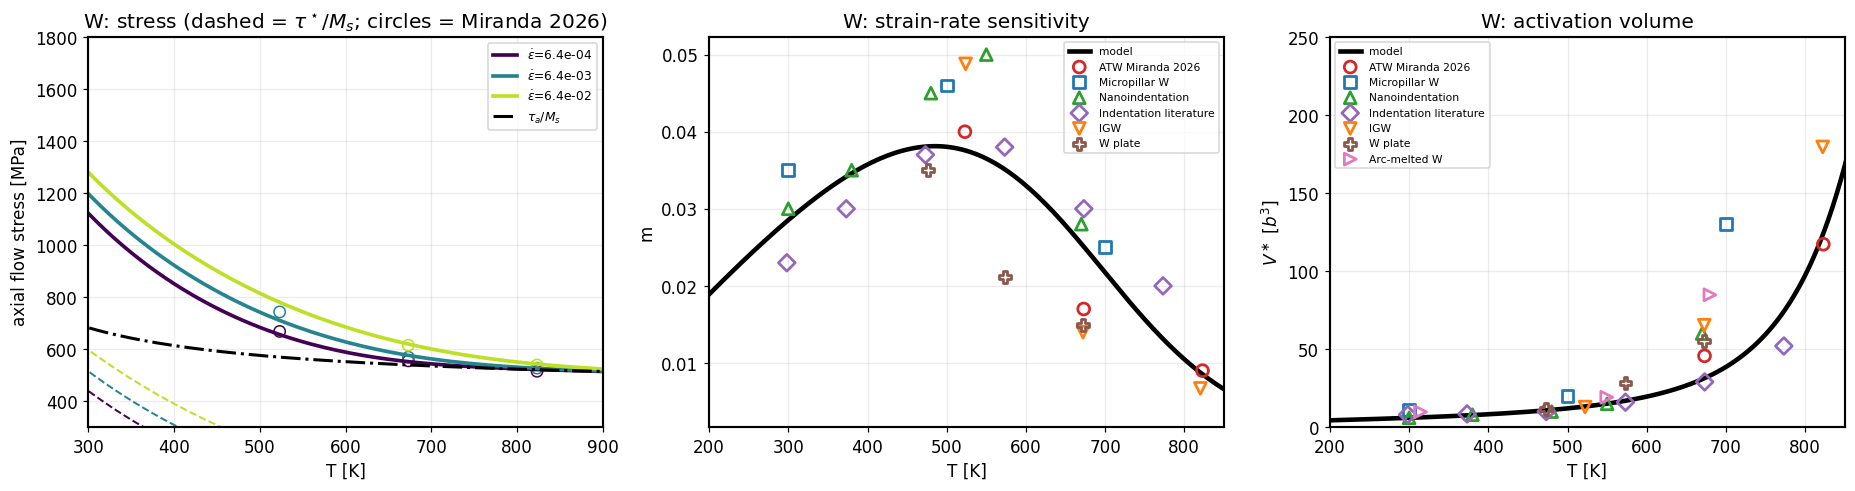

In [3]:
W = make_W()
TW = np.linspace(200, 900, 141)
fig, axs = plt.subplots(1, 3, figsize=(17, 4.6))
cols = plt.cm.viridis(np.linspace(0, 0.9, 3))
for c, e in zip(cols, W_RATES):
    r = W.solve(e/W_M, TW)
    axs[0].plot(TW, r["tau"]/W_M/1e6, color=c, lw=2.4, label=fr"$\dot\epsilon$={e:.1e}")
    axs[0].plot(TW, r["tau_star"]/W_M/1e6, "--", color=c, lw=1.3)
    k = np.isclose(W_DATA["flow"][:, 1], e)
    axs[0].scatter(W_DATA["flow"][k, 0], W_DATA["flow"][k, 2], s=55, facecolors="none", edgecolors=c)
axs[0].plot(TW, r["tau_a"]/W_M/1e6, "k-.", lw=2, label=r"$\tau_a/M_s$")
axs[0].set(xlabel="T [K]", ylabel="axial flow stress [MPa]", xlim=(300, 900), ylim=(300, 1800),
           title="W: stress (dashed = $\\tau^\\star/M_s$; circles = Miranda 2026)"); axs[0].legend(fontsize=8)

gW = W.global_m_V(W_RATES, TW, W_M)
axs[1].plot(TW, gW["m"], "k", lw=3, label="model"); scatter_sets(axs[1], W_DATA["m"])
axs[1].set(xlabel="T [K]", ylabel="m", xlim=(200, 850), title="W: strain-rate sensitivity"); axs[1].legend(fontsize=7)
axs[2].plot(TW, gW["Vstar_b3"], "k", lw=3, label="model"); scatter_sets(axs[2], W_DATA["V"])
axs[2].set(xlabel="T [K]", ylabel=r"$V^\ast$ [$b^3$]", xlim=(200, 850), ylim=(0, 250), title="W: activation volume")
axs[2].legend(fontsize=7)
plt.tight_layout(); plt.show()

rW = W.srs(6.4e-3/W_M, TW)
print("max |Lambda| for W over 200-900 K:", float(np.nanmax(np.abs(rW["Lambda"]))))

---
## 2. HCP zirconium: DSA by oxygen and glide-assisted climb
Three ingredients are the same as in W: kink-pair travel on prismatic screws, and a Taylor forest $\tau_a$ from Kocks–Mecking. Two more make the state depend on rate:

* **O atmospheres** age the forest junctions: $\tau_a\to\tau_a\sqrt{C/C_0}$, with aging time $t_a=\rho_mb\lambda/\dot\gamma$. This gives $B<0$, the plateau/hump, and the dip in $m$.
* **Climb-controlled recovery** of the forest: $\dot\rho=-K_{cl}D(T)\rho^2$. This gives $B>0$ and the high-temperature drop, with $m$ rising toward the $n=3$ limit.

The original notebook's sigmoid $S_O(T)$ and Jennings-type resistance are not used. The CRSS data are $\sigma/3$ (Derep), as in the original notebook.

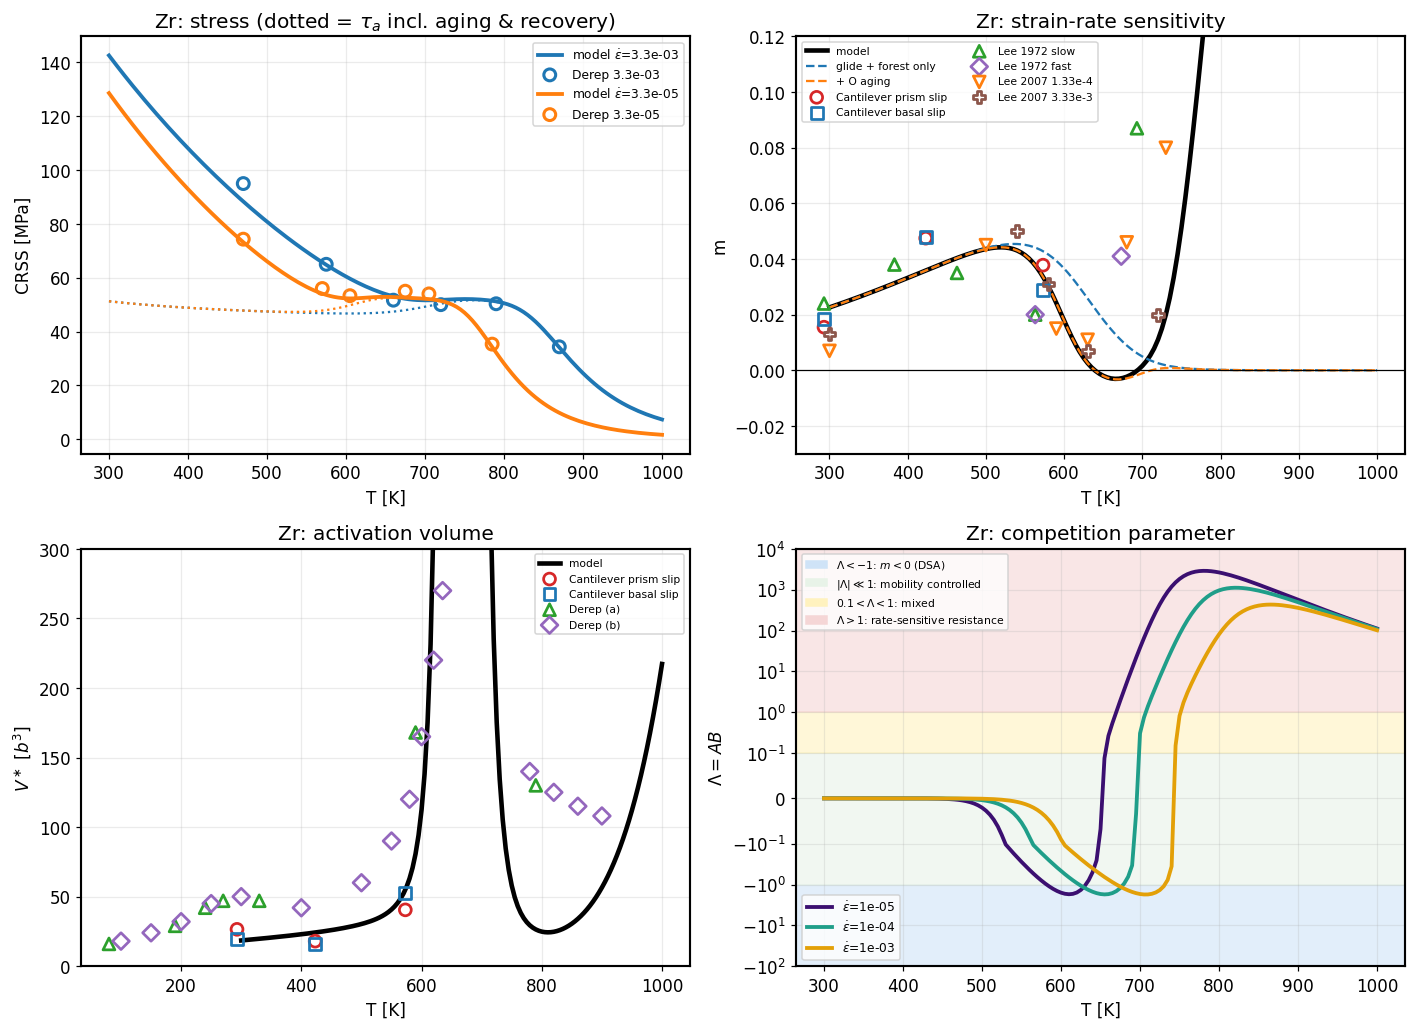

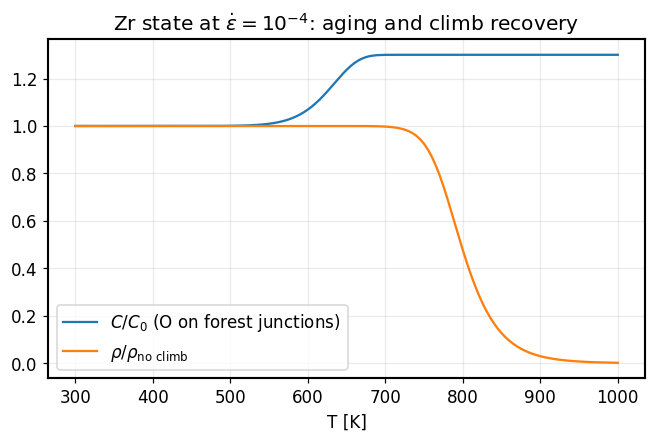

In [4]:
Zr = make_Zr()
TZ = np.linspace(300, 1000, 141)
fig, axs = plt.subplots(2, 2, figsize=(13, 9.5))
ax = axs[0, 0]
for c, e in zip(["tab:blue", "tab:orange"], [3.3e-3, 3.3e-5]):
    r = Zr.solve(e/ZR_M, TZ)
    ax.plot(TZ, r["tau"]/1e6, color=c, lw=2.5, label=fr"model $\dot\epsilon$={e:.1e}")
    ax.plot(TZ, r["tau_a"]/1e6, ":", color=c, lw=1.5)
    T, y = ZR_DATA["crss"][e]
    ax.scatter(T, y, s=60, facecolors="none", edgecolors=c, linewidths=2, label=fr"Derep {e:.1e}")
ax.set(xlabel="T [K]", ylabel="CRSS [MPa]", title=r"Zr: stress (dotted = $\tau_a$ incl. aging & recovery)"); ax.legend(fontsize=8)

gZ = Zr.global_m_V(ZR_RATES, TZ, ZR_M)
ax = axs[0, 1]
ax.plot(TZ, gZ["m"], "k", lw=3, label="model")
for lab, kw in [("glide + forest only", dict(aging=False, climb=False)), ("+ O aging", dict(aging=True, climb=False))]:
    ax.plot(TZ, make_Zr(**kw).global_m_V(ZR_RATES, TZ, ZR_M)["m"], lw=1.5, ls="--", label=lab)
scatter_sets(ax, ZR_DATA["m"]); ax.set(xlabel="T [K]", ylabel="m", ylim=(-0.03, 0.12), title="Zr: strain-rate sensitivity")
ax.axhline(0, color="k", lw=0.8); ax.legend(fontsize=7, ncol=2)

ax = axs[1, 0]
ax.plot(TZ, gZ["Vstar_b3"], "k", lw=3, label="model"); scatter_sets(ax, ZR_DATA["V"])
ax.set(xlabel="T [K]", ylabel=r"$V^\ast$ [$b^3$]", ylim=(0, 300), title="Zr: activation volume"); ax.legend(fontsize=7)

ax = axs[1, 1]
handles = shade_lambda(ax)
for c, e in zip(["#3B0F70", "#1F9E89", "#E3A008"], ZR_RATES):
    ax.plot(TZ, Zr.srs(e/ZR_M, TZ)["Lambda"], color=c, lw=2.5, label=fr"$\dot\epsilon$={e:.0e}")
leg = ax.legend(handles=handles, fontsize=7, loc="upper left"); ax.add_artist(leg); ax.legend(fontsize=8, loc="lower left")
ax.set(xlabel="T [K]", ylabel=r"$\Lambda=AB$", ylim=(-100, 1e4), title="Zr: competition parameter")
plt.tight_layout(); plt.show()

r = Zr.solve(1e-4/ZR_M, TZ)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(TZ, r["C_C0"], label=r"$C/C_0$ (O on forest junctions)")
rho0 = make_Zr(climb=False).solve(1e-4/ZR_M, TZ)["rho_f"]
ax.plot(TZ, r["rho_f"]/rho0, label=r"$\rho/\rho_{\rm no\ climb}$")
ax.set(xlabel="T [K]", title=r"Zr state at $\dot\epsilon=10^{-4}$: aging and climb recovery"); ax.legend(); plt.show()

---
## 3. Eurofer-97: kink pairs, DSA and precipitate bypass
* **Travel:** Fe-type kink-pair glide.
* **$\tau_a$:** athermal forest plus lath/block/PAG boundaries, from Kocks–Mecking with boundary storage (inputs from the original script).
* **C/N aging** of the forest. This gives the flat, non-monotonic region at 473–673 K.
* **Climb-controlled recovery** of the forest (same form as in Zr).
* **Precipitate group** (MX, M$_{23}$C$_6$), acting simultaneously with the forest. It is passed by thermally activated detachment *or* by glide-assisted local climb (Brown–Ham type height reduction). This gives the strongly rate-dependent drop above ~700 K.

Data: Vanaja et al., JNM 424 (2012), $\sigma_s/3$.

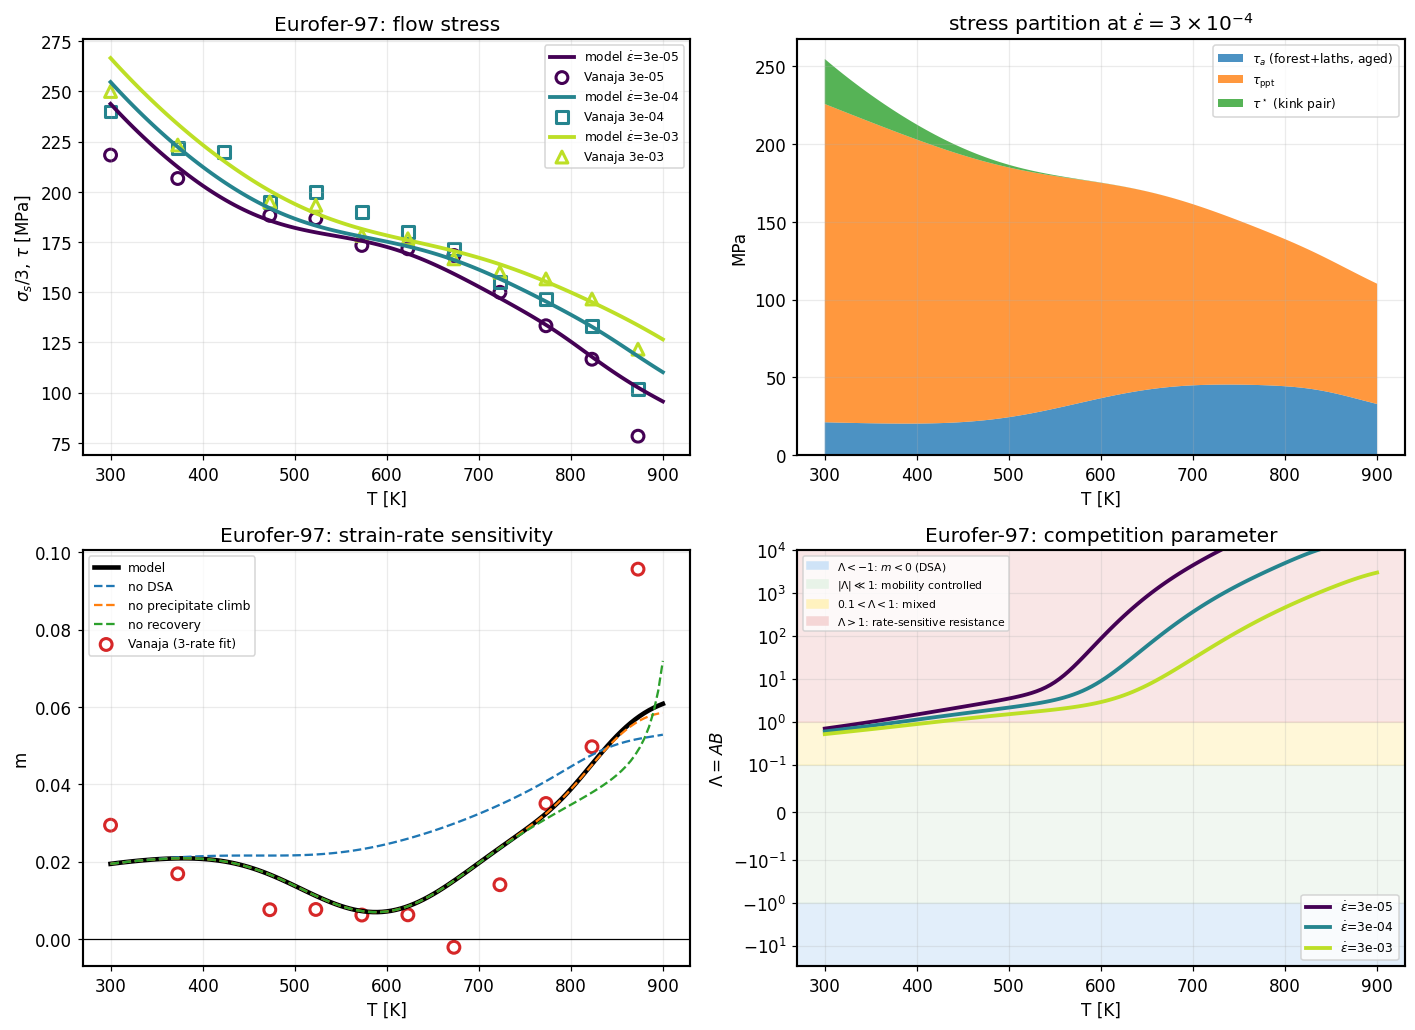

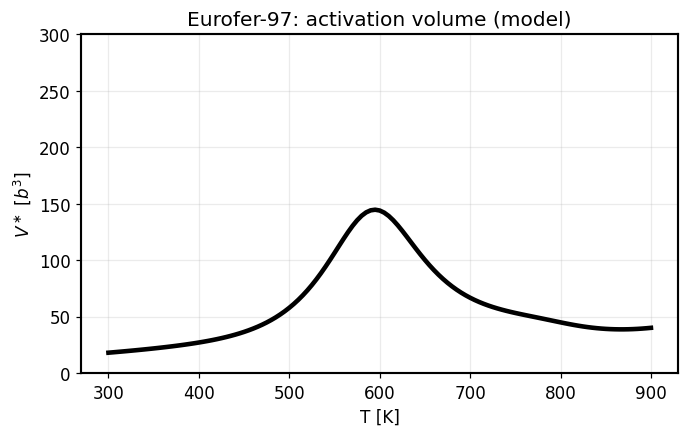

In [5]:
EU = make_Eurofer()
TE = np.linspace(300, 900, 121)
fig, axs = plt.subplots(2, 2, figsize=(13, 9.5))
cols = plt.cm.viridis(np.linspace(0, 0.9, 3))
ax = axs[0, 0]
for j, (c, e) in enumerate(zip(cols, EU_RATES)):
    r = EU.solve(e/EU_M, TE)
    ax.plot(TE, r["tau"]/1e6, color=c, lw=2.5, label=fr"model $\dot\epsilon$={e:.0e}")
    y = EU_DATA["sigma"][:, j]/3; k = np.isfinite(y)
    ax.scatter(EU_DATA["T"][k], y[k], s=60, marker=MARK[j], facecolors="none", edgecolors=c, linewidths=2,
               label=fr"Vanaja {e:.0e}")
ax.set(xlabel="T [K]", ylabel=r"$\sigma_s/3$, $\tau$ [MPa]", title="Eurofer-97: flow stress"); ax.legend(fontsize=8)

ax = axs[0, 1]
r = EU.solve(3e-4/EU_M, TE)
ax.stackplot(TE, r["tau_a"]/1e6, r["tau_precipitates"]/1e6, r["tau_star"]/1e6,
             labels=[r"$\tau_a$ (forest+laths, aged)", r"$\tau_{\rm ppt}$", r"$\tau^\star$ (kink pair)"], alpha=0.8)
ax.set(xlabel="T [K]", ylabel="MPa", title=r"stress partition at $\dot\epsilon=3\times10^{-4}$"); ax.legend(fontsize=8)

gE = EU.global_m_V(EU_RATES, TE, EU_M)
TT, RR = np.meshgrid(EU_DATA["T"], EU_RATES, indexing="ij")
sig = EU_DATA["sigma"]
L = np.log(EU_RATES); m_exp = []
for i in range(len(EU_DATA["T"])):
    k = np.isfinite(sig[i]); m_exp.append(np.polyfit(L[k], np.log(sig[i][k]), 1)[0] if k.sum() >= 3 else np.nan)
ax = axs[1, 0]
ax.plot(TE, gE["m"], "k", lw=3, label="model")
for lab, kw in [("no DSA", dict(aging=False)), ("no precipitate climb", dict(climb=False)), ("no recovery", dict(recovery=False))]:
    ax.plot(TE, make_Eurofer(**kw).global_m_V(EU_RATES, TE, EU_M)["m"], "--", lw=1.5, label=lab)
ax.scatter(EU_DATA["T"], m_exp, s=60, facecolors="none", edgecolors="tab:red", linewidths=2, label="Vanaja (3-rate fit)")
ax.axhline(0, color="k", lw=0.8); ax.set(xlabel="T [K]", ylabel="m", title="Eurofer-97: strain-rate sensitivity"); ax.legend(fontsize=8)

ax = axs[1, 1]
handles = shade_lambda(ax)
for c, e in zip(cols, EU_RATES):
    ax.plot(TE, EU.srs(e/EU_M, TE)["Lambda"], color=c, lw=2.5, label=fr"$\dot\epsilon$={e:.0e}")
leg = ax.legend(handles=handles, fontsize=7, loc="upper left"); ax.add_artist(leg); ax.legend(fontsize=8, loc="lower right")
ax.set(xlabel="T [K]", ylabel=r"$\Lambda=AB$", ylim=(-30, 1e4), title="Eurofer-97: competition parameter")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(TE, gE["Vstar_b3"], "k", lw=3)
ax.set(xlabel="T [K]", ylabel=r"$V^\ast$ [$b^3$]", ylim=(0, 300), title="Eurofer-97: activation volume (model)"); plt.show()

---
## 4. All three materials in one picture
The same equation and the same diagnostics apply to all three. What differs is which process holds the time and which state variables depend on rate.

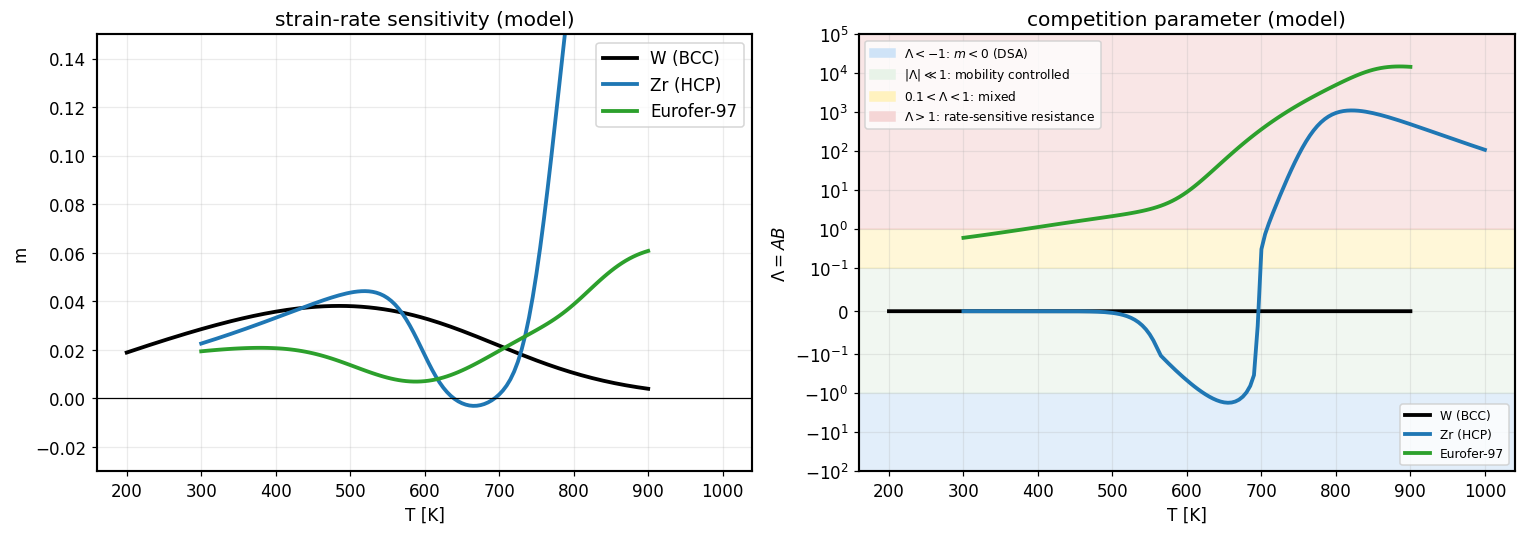

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
cases = [("W (BCC)", W, W_RATES, W_M, np.linspace(200, 900, 141), 5e-3),
         ("Zr (HCP)", Zr, ZR_RATES, ZR_M, np.linspace(300, 1000, 141), 1e-4),
         ("Eurofer-97", EU, EU_RATES, EU_M, np.linspace(300, 900, 121), 3e-4)]
cc = ["k", "tab:blue", "tab:green"]
handles = shade_lambda(axs[1])
for (name, mdl, rates, M, T, eref), c in zip(cases, cc):
    axs[0].plot(T, mdl.global_m_V(rates, T, M)["m"], color=c, lw=2.5, label=name)
    axs[1].plot(T, mdl.srs(eref/M, T)["Lambda"], color=c, lw=2.5, label=name)
axs[0].axhline(0, color="k", lw=0.8)
axs[0].set(xlabel="T [K]", ylabel="m", ylim=(-0.03, 0.15), title="strain-rate sensitivity (model)"); axs[0].legend()
leg = axs[1].legend(handles=handles, fontsize=8, loc="upper left"); axs[1].add_artist(leg); axs[1].legend(fontsize=8, loc="lower right")
axs[1].set(xlabel="T [K]", ylabel=r"$\Lambda=AB$", ylim=(-100, 1e5), title="competition parameter (model)")
plt.tight_layout(); plt.show()

In [7]:
# Parameter cards used above
import pprint
for name, P in [("W", W_P), ("Zr", ZR_P), ("Eurofer-97", EU_P)]:
    print(f"--- {name} ---"); pprint.pprint(P, compact=True, width=110)

--- W ---
{'B_kink': np.float64(0.0011004349282215645),
 'D0_rec': 4e-05,
 'Db0': 4e-05,
 'K_cl': 1000000000.0,
 'QD_rec_eV': 6.0,
 'Qb_eV': 3.9,
 'T0_frac': 0.9,
 'alpha': 0.549,
 'dH0_eV': 2.52,
 'd_grain': 0.0001,
 'k1': 5500000000.0,
 'k20': 891.0,
 'p': 0.6,
 'q': 1.4,
 'q2_eV': -0.011,
 'tau_P': 700000000.0}
--- Zr ---
{'B_free': 5e-05,
 'B_kink': np.float64(0.0007654655446197432),
 'C_O': 0.3,
 'D0': 0.0001,
 'Db0': 0.0001,
 'K_cl': 1000000000.0,
 'QD_eV': 3.2,
 'Q_O_eV': 1.8,
 'Qb_eV': 2.1,
 'T0_frac': 0.7,
 'alpha': 0.36,
 'alpha_O': 0.6666666666666666,
 'dH0_eV': 3.75,
 'd_grain': 2e-05,
 'k1': 5500000000.0,
 'k20': 500.0,
 'nu_O': 10000000000000.0,
 'p': 0.86,
 'q': 1.69,
 'q2_eV': -0.005,
 'tau_P': 300000000.0}
--- Eurofer-97 ---
{'B_kink': np.float64(0.0008750446417183526),
 'C_CN': 6.0,
 'D0_climb': 0.10811849705944694,
 'D0_rec': 0.0002,
 'Db0': 0.0002,
 'F_det_eV': 3.556,
 'K_cl': 850354.4719998013,
 'QD_climb_eV': 3.226,
 'QD_rec_eV': 2.772,
 'Q_CN_eV': 1.625,
 'Qb_eV'

### Notes on the calibration
* **W** uses the original parameters unchanged; the model reproduces the original notebook exactly.
* **Zr:** the kink-pair parameters ($\Delta H_0=3.75$ eV, $\tau_P=300$ MPa), $\alpha$, the O-aging parameters ($C=0.3$, $Q_{\rm eff}=1.8$ eV) and the climb-recovery parameters ($Q_D=3.2$ eV, $K_{cl}D_0$) were fitted to the two Derep CRSS rates, with a weak weight on $m$. The fit reproduces the CRSS to within about 7%. $V^\ast$ below 550 K is about a factor of 2 below the Derep values, as it also was with the original parameters.
* **Eurofer-97:** all parameters were fitted jointly to Vanaja's 3-rate flow stresses (mean absolute error 4.1%) and to 54 minimum creep rates (Fernández et al. 2005; Yu et al. 2005; rms error 0.55 decades; see `BCC_creep_maps.ipynb`). The fitted pieces are the kink pair, DSA ($Q_{\rm eff}=0.97$ eV for C/N, close to C migration in ferrite), the precipitate group (detachment $F=3.7$ eV, or local climb), and forest recovery. Climb and recovery share one diffusivity with $Q_D=2.92$ eV. Their prefactors are lumped with geometry and are not bare diffusivities.